In [1]:
import numpy as np
import pandas as pd
import json
from scipy.spatial.distance import cdist
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import nomad.io.base as loader

## Load Data

In [2]:
with open('config_2_stops.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

sparse_df = loader.from_file(config["output_files"]["sparse_path"], format="parquet")
sparse_df.drop(columns=['datetime'], inplace=True)

diaries_df = loader.from_file(config["output_files"]["diaries_path"], format="parquet").rename(
    columns={"identifier": "user_id"}
)

In [3]:
sparse_df

,x,y,timestamp,user_id,ha,tz_offset
0,-4.265454e+06,4.393148e+06,1717214853,admiring_keller,15.0,-14400
1,-4.265466e+06,4.393130e+06,1717215368,admiring_keller,15.0,-14400
2,-4.265422e+06,4.393144e+06,1717216320,admiring_keller,15.0,-14400
3,-4.265447e+06,4.393147e+06,1717216540,admiring_keller,15.0,-14400
4,-4.265441e+06,4.393152e+06,1717216701,admiring_keller,15.0,-14400
...,...,...,...,...,...,...
6423,-4.265390e+06,4.393136e+06,1717222776,zen_mayer,15.0,-14400
6424,-4.265418e+06,4.393180e+06,1717223556,zen_mayer,15.0,-14400
6425,-4.265389e+06,4.393150e+06,1717224374,zen_mayer,15.0,-14400
6426,-4.265411e+06,4.393152e+06,1717224689,zen_mayer,15.0,-14400


In [4]:
diaries_df

,datetime,timestamp,duration,location,user_id,x,y,tz_offset
0,2024-06-01 00:00:09,1717214409,90,w-x17-y10,admiring_keller,-4265429.0,4393133.5,-14400
1,2024-06-01 01:30:09,1717219809,0,None,admiring_keller,NaN,NaN,-14400
2,2024-06-01 01:31:03,1717219863,89,r-x19-y11,admiring_keller,-4265414.0,4393148.5,-14400
3,2024-06-01 00:00:09,1717214409,90,w-x17-y10,admiring_mestorf,-4265429.0,4393133.5,-14400
4,2024-06-01 01:30:09,1717219809,0,None,admiring_mestorf,NaN,NaN,-14400
...,...,...,...,...,...,...,...,...
745,2024-06-01 01:30:09,1717219809,0,None,zen_elion,NaN,NaN,-14400
746,2024-06-01 01:31:03,1717219863,89,r-x19-y11,zen_elion,-4265414.0,4393148.5,-14400
747,2024-06-01 00:00:09,1717214409,90,w-x17-y10,zen_mayer,-4265429.0,4393133.5,-14400
748,2024-06-01 01:30:09,1717219809,1,None,zen_mayer,NaN,NaN,-14400


## Split sparse_df into chunks using diary time intervals

Each diary entry with `duration > 0` defines a time interval `[timestamp, timestamp + duration * 60]`.
We assign each sparse ping to the diary chunk whose interval contains it.

In [5]:
# Filter out transition diary entries (duration == 0 or no location)
valid_diaries = diaries_df[diaries_df['duration'] > 0].copy()
valid_diaries['end_timestamp'] = valid_diaries['timestamp'] + valid_diaries['duration'] * 60

print(f"Diary entries with duration > 0: {len(valid_diaries)}")
print(valid_diaries[['user_id', 'timestamp', 'end_timestamp', 'duration', 'location']].head(6))

Diary entries with duration > 0: 668
            user_id   timestamp  end_timestamp  duration   location
0   admiring_keller  1717214409     1717219809        90  w-x17-y10
2   admiring_keller  1717219863     1717225203        89  r-x19-y11
3  admiring_mestorf  1717214409     1717219809        90  w-x17-y10
5  admiring_mestorf  1717219854     1717225194        89  r-x19-y11
6  admiring_neumann  1717214409     1717219809        90  w-x17-y10
7  admiring_neumann  1717219809     1717219869         1       None


In [6]:
max_cross_chunk_distances = []
median_distances = []

users = sparse_df['user_id'].unique()

for user in tqdm(users, desc='Processing users'):
    user_sparse = sparse_df[sparse_df['user_id'] == user]
    user_diaries = valid_diaries[valid_diaries['user_id'] == user].sort_values('timestamp')

    # Build one array of (x, y) coords per diary chunk
    chunks = []
    for _, row in user_diaries.iterrows():
        mask = (user_sparse['timestamp'] >= row['timestamp']) & (user_sparse['timestamp'] <= row['end_timestamp'])
        chunk_coords = user_sparse.loc[mask, ['x', 'y']].values
        chunks.append(chunk_coords)

    # Only proceed if we have at least 2 non-empty chunks
    non_empty = [c for c in chunks if len(c) > 0]
    if len(non_empty) < 2:
        continue

    # --- Histogram 1: max distance between any two points in *different* chunks ---
    max_dist = 0.0
    for i in range(len(non_empty)):
        for j in range(i + 1, len(non_empty)):
            cross_dists = cdist(non_empty[i], non_empty[j], metric='euclidean')
            max_dist = max(max_dist, cross_dists.max())
    max_cross_chunk_distances.append(max_dist)

    # --- Histogram 2: distance between the medians of each chunk ---
    medians = np.array([np.median(c, axis=0) for c in non_empty])  # shape (n_chunks, 2)
    for i in range(len(medians)):
        for j in range(i + 1, len(medians)):
            dist = np.linalg.norm(medians[i] - medians[j])
            median_distances.append(dist)

max_cross_chunk_distances = np.array(max_cross_chunk_distances)
median_distances = np.array(median_distances)

print(f"Users with valid chunk pairs: {len(max_cross_chunk_distances)}")
print(f"Max cross-chunk distance  — mean: {max_cross_chunk_distances.mean():.1f} m, "
      f"median: {np.median(max_cross_chunk_distances):.1f} m")
print(f"Median-to-median distance — mean: {median_distances.mean():.1f} m, "
      f"median: {np.median(median_distances):.1f} m")

Processing users: 100%|██████████| 250/250 [00:00<00:00, 328.72it/s]

Users with valid chunk pairs: 250
Max cross-chunk distance  — mean: 88.6 m, median: 88.4 m
Median-to-median distance — mean: 43.8 m, median: 45.6 m


## Histograms

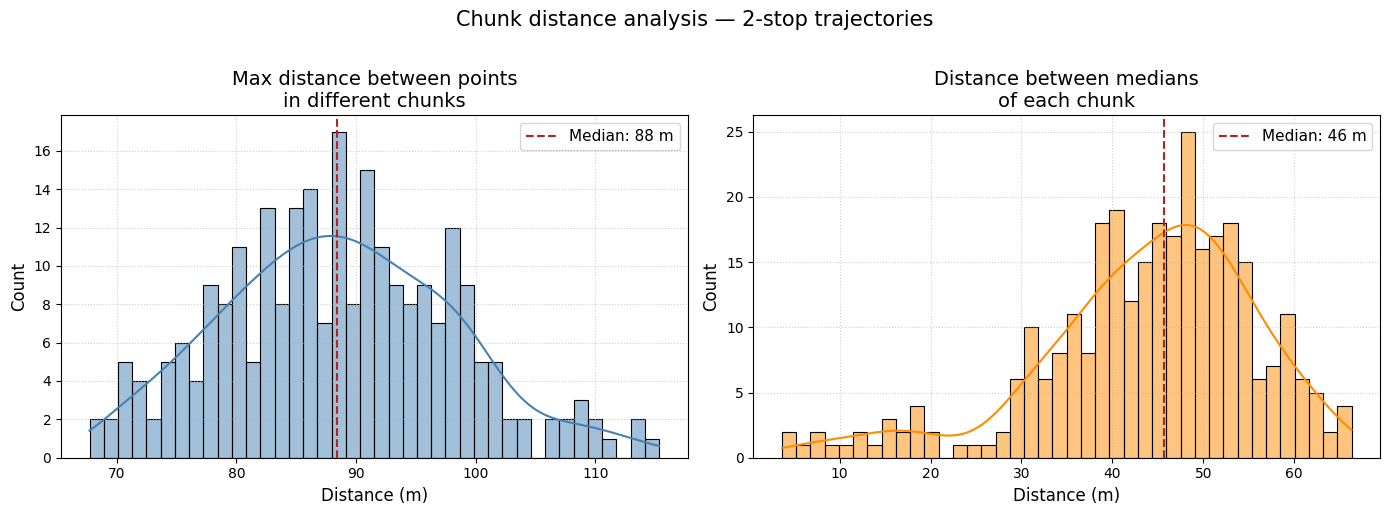

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: max cross-chunk point distance ---
sns.histplot(max_cross_chunk_distances, bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(np.median(max_cross_chunk_distances), color='firebrick', linestyle='--',
                linewidth=1.5, label=f'Median: {np.median(max_cross_chunk_distances):.0f} m')
axes[0].set_title('Max distance between points\nin different chunks', fontsize=14)
axes[0].set_xlabel('Distance (m)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: distance between chunk medians ---
sns.histplot(median_distances, bins=40, kde=True, ax=axes[1], color='darkorange')
axes[1].axvline(np.median(median_distances), color='firebrick', linestyle='--',
                linewidth=1.5, label=f'Median: {np.median(median_distances):.0f} m')
axes[1].set_title('Distance between medians\nof each chunk', fontsize=14)
axes[1].set_xlabel('Distance (m)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

fig.suptitle('Chunk distance analysis — 2-stop trajectories', fontsize=15, y=1.02)
fig.tight_layout()
plt.show()